## 说明

请按照填空顺序编号分别完成 参数优化，不同基函数的实现

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def load_data(filename):
    """载入数据。"""
    xys = []
    with open(filename, 'r') as f:
        for line in f:
            xys.append(map(float, line.strip().split()))
        xs, ys = zip(*xys)
        return np.asarray(xs), np.asarray(ys)

## 不同的基函数 (basis function)的实现 填空顺序 2

请分别在这里实现“多项式基函数”以及“高斯基函数”

其中以及训练集的x的范围在0-25之间

In [2]:
def identity_basis(x):
    ret = np.expand_dims(x, axis=1)
    return ret

def multinomial_basis(x, feature_num=10):
    '''多项式基函数'''
    x = np.expand_dims(x, axis=1) # shape(N, 1)
    #==========
    #todo '''请实现多项式基函数'''
    # 这里不包含常数项，常数项会在 main() 里单独拼接
    ret = np.concatenate([x ** i for i in range(1, feature_num + 1)], axis=1)
    #==========
    return ret

def gaussian_basis(x, feature_num=10):
    '''高斯基函数'''
    #==========
    #todo '''请实现高斯基函数'''
    x = np.expand_dims(x, axis=1) # shape(N, 1)
    centers = np.linspace(0, 25, feature_num)
    width = centers[1] - centers[0] if feature_num > 1 else 1.0
    ret = np.exp(-((x - centers) ** 2) / (2 * width ** 2))
    #==========
    return ret

## 返回一个训练好的模型 填空顺序 1 用最小二乘法进行模型优化 
## 填空顺序 3 用梯度下降进行模型优化
> 先完成最小二乘法的优化 (参考书中第二章 2.3中的公式)

> 再完成梯度下降的优化   (参考书中第二章 2.3中的公式)

在main中利用训练集训练好模型的参数，并且返回一个训练好的模型。

计算出一个优化后的w，请分别使用最小二乘法以及梯度下降两种办法优化w

In [3]:
def main(x_train, y_train, basis_func=None, optimize_method='least_squares'):
    """
    训练模型，并返回从x到y的映射。
    
    """
    if basis_func is None:
        basis_func = lambda x: gaussian_basis(x, feature_num=20)
    phi0 = np.expand_dims(np.ones_like(x_train), axis=1)
    phi1 = basis_func(x_train)
    phi = np.concatenate([phi0, phi1], axis=1)
    
    
    #==========
    #todo '''计算出一个优化后的w，请分别使用最小二乘法以及梯度下降两种办法优化w'''
    if optimize_method == 'least_squares':
        # 最小二乘法闭式解: w = (Phi^T Phi)^(-1) Phi^T y
        w = np.linalg.pinv(phi.T @ phi) @ phi.T @ y_train
    elif optimize_method == 'gradient_descent':
        # 梯度下降法
        w = np.zeros(phi.shape[1])
        learning_rate = 5e-2
        steps = 50000
        sample_num = x_train.shape[0]
        for _ in range(steps):
            grad = phi.T @ (phi @ w - y_train) / sample_num
            w -= learning_rate * grad
    else:
        raise ValueError('Unknown optimize_method: {}'.format(optimize_method))
    #==========
    
    def f(x):
        phi0 = np.expand_dims(np.ones_like(x), axis=1)
        phi1 = basis_func(x)
        phi = np.concatenate([phi0, phi1], axis=1)
        y = np.dot(phi, w)
        return y

    return f

## 评估结果 
> 没有需要填写的代码，但是建议读懂

(300,)
(200,)
最小二乘法 训练集预测值与真实值的标准差：0.099
最小二乘法 测试集预测值与真实值的标准差：0.116
梯度下降法 训练集预测值与真实值的标准差：0.160
梯度下降法 测试集预测值与真实值的标准差：0.188


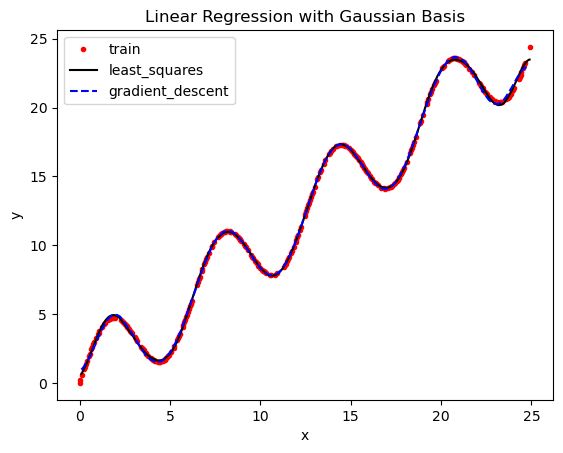

In [4]:
def evaluate(ys, ys_pred):
    """评估模型。"""
    std = np.sqrt(np.mean(np.abs(ys - ys_pred) ** 2))
    return std

# 程序主入口（建议不要改动以下函数的接口）
if __name__ == '__main__':
    train_file = 'train.txt'
    test_file = 'test.txt'
    # 载入数据
    x_train, y_train = load_data(train_file)
    x_test, y_test = load_data(test_file)
    print(x_train.shape)
    print(x_test.shape)

    basis_func = lambda x: gaussian_basis(x, feature_num=20)

    # 使用同一组高斯基函数，分别比较最小二乘法和梯度下降法
    f_ls = main(x_train, y_train, basis_func=basis_func, optimize_method='least_squares')
    f_gd = main(x_train, y_train, basis_func=basis_func, optimize_method='gradient_descent')

    y_train_pred_ls = f_ls(x_train)
    y_test_pred_ls = f_ls(x_test)
    print('最小二乘法 训练集预测值与真实值的标准差：{:.3f}'.format(evaluate(y_train, y_train_pred_ls)))
    print('最小二乘法 测试集预测值与真实值的标准差：{:.3f}'.format(evaluate(y_test, y_test_pred_ls)))

    y_train_pred_gd = f_gd(x_train)
    y_test_pred_gd = f_gd(x_test)
    print('梯度下降法 训练集预测值与真实值的标准差：{:.3f}'.format(evaluate(y_train, y_train_pred_gd)))
    print('梯度下降法 测试集预测值与真实值的标准差：{:.3f}'.format(evaluate(y_test, y_test_pred_gd)))

    #显示结果
    plt.plot(x_train, y_train, 'ro', markersize=3)
    plt.plot(x_test, y_test_pred_ls, 'k')
    plt.plot(x_test, y_test_pred_gd, 'b--')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Linear Regression with Gaussian Basis')
    plt.legend(['train', 'least_squares', 'gradient_descent'])
    plt.show()